# Electron Density Evolution using Graph Neural Networks

This notebook explores modeling electron density evolution as a temporal graph problem.

**Goal**: Predict electron density at future timesteps given current density states.

**Approach**: 
- Treat each grid point as a node in a graph
- Model spatial relationships between grid points as edges
- Use GNNs to learn temporal evolution patterns

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.utils import add_self_loops, degree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.10.0+cpu
Device: cpu


## 2. Data Loading and Exploration

In [2]:
# Define data paths
ammonia_dir = Path('ammonia_x')
water_dir = Path('water_x')

def load_density_file(filepath):
    """Load a single electron density file"""
    data = np.loadtxt(filepath, usecols=1)  # Column 2 has density values
    return data

def get_all_timestep_files(directory):
    """Get all density files sorted by timestep"""
    files = sorted(glob.glob(str(directory / 'rvlab.tdscf.rho.*')))
    return files

# Load ammonia data
ammonia_files = get_all_timestep_files(ammonia_dir)
water_files = get_all_timestep_files(water_dir)

print(f"Ammonia files: {len(ammonia_files)}")
print(f"Water files: {len(water_files)}")
print(f"\nFirst few ammonia files:\n{ammonia_files[:5]}")

Ammonia files: 401
Water files: 401

First few ammonia files:
['ammonia_x/rvlab.tdscf.rho.00000', 'ammonia_x/rvlab.tdscf.rho.00005', 'ammonia_x/rvlab.tdscf.rho.00010', 'ammonia_x/rvlab.tdscf.rho.00015', 'ammonia_x/rvlab.tdscf.rho.00020']


In [3]:
# Load a sample to understand the data
sample_ammonia = load_density_file(ammonia_files[0])
sample_water = load_density_file(water_files[0])

print(f"Ammonia grid points: {len(sample_ammonia)}")
print(f"Water grid points: {len(sample_water)}")
print(f"\nAmmonia density stats:")
print(f"  Mean: {sample_ammonia.mean():.6f}")
print(f"  Std: {sample_ammonia.std():.6f}")
print(f"  Min: {sample_ammonia.min():.6f}")
print(f"  Max: {sample_ammonia.max():.6f}")
print(f"\nWater density stats:")
print(f"  Mean: {sample_water.mean():.6f}")
print(f"  Std: {sample_water.std():.6f}")
print(f"  Min: {sample_water.min():.6f}")
print(f"  Max: {sample_water.max():.6f}")

Ammonia grid points: 10540
Water grid points: 8062

Ammonia density stats:
  Mean: 10.066125
  Std: 40.032082
  Min: 0.000000
  Max: 196.639108

Water density stats:
  Mean: 19.902908
  Std: 68.776023
  Min: 0.000000
  Max: 298.349428


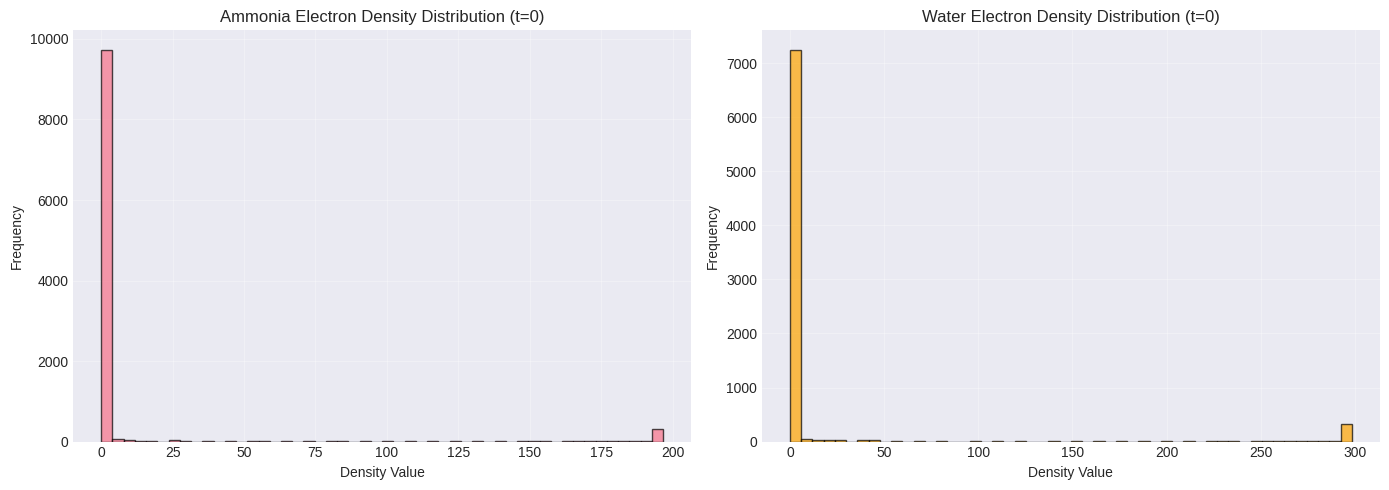

In [4]:
# Visualize density distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample_ammonia, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Ammonia Electron Density Distribution (t=0)', fontsize=12)
axes[0].set_xlabel('Density Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(sample_water, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Water Electron Density Distribution (t=0)', fontsize=12)
axes[1].set_xlabel('Density Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ammonia time series shape: (10, 10540)
Water time series shape: (10, 8062)


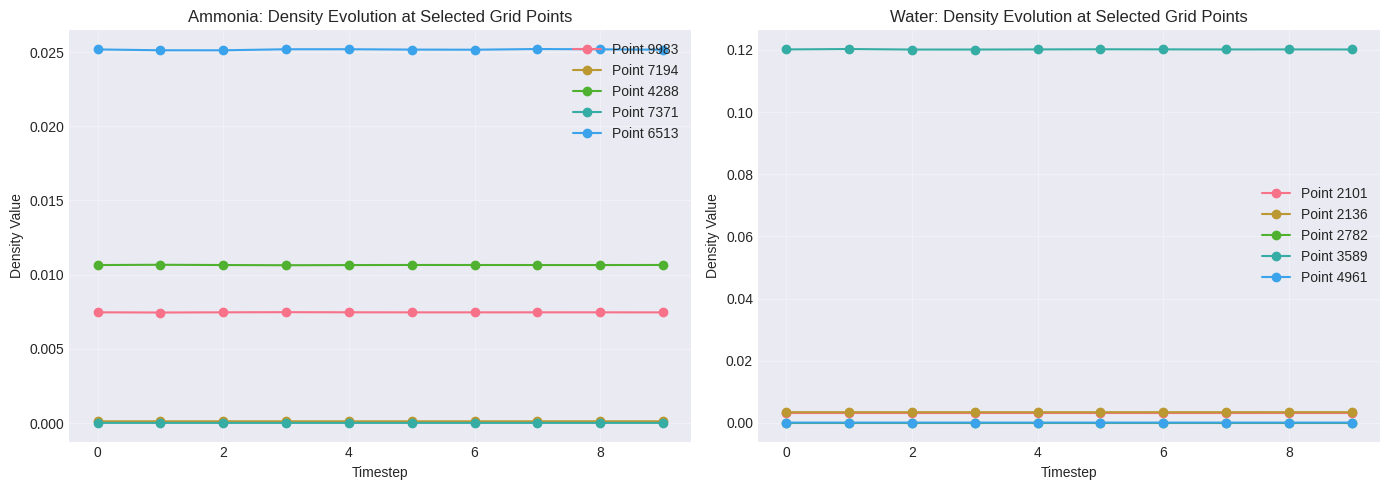

In [5]:
# Load multiple timesteps to analyze temporal evolution
n_samples = 10
ammonia_timeseries = np.array([load_density_file(f) for f in ammonia_files[:n_samples]])
water_timeseries = np.array([load_density_file(f) for f in water_files[:n_samples]])

print(f"Ammonia time series shape: {ammonia_timeseries.shape}")  # (timesteps, grid_points)
print(f"Water time series shape: {water_timeseries.shape}")

# Plot evolution of some grid points over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample 5 random grid points
sample_points = np.random.choice(len(sample_ammonia), 5, replace=False)

for i, point in enumerate(sample_points):
    axes[0].plot(ammonia_timeseries[:, point], label=f'Point {point}', marker='o')
axes[0].set_title('Ammonia: Density Evolution at Selected Grid Points', fontsize=12)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Density Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sample_points_water = np.random.choice(len(sample_water), 5, replace=False)
for i, point in enumerate(sample_points_water):
    axes[1].plot(water_timeseries[:, point], label=f'Point {point}', marker='o', color=f'C{i}')
axes[1].set_title('Water: Density Evolution at Selected Grid Points', fontsize=12)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Density Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Graph Construction

Since we don't have explicit spatial coordinates, we'll construct a graph based on:
1. **k-NN in feature space**: Connect nodes whose density values are similar
2. **Sequential neighbors**: Connect adjacent grid point indices
3. **Fully connected** (for small graphs): Connect all nodes

In [6]:
def build_sequential_edges(num_nodes, k=5):
    """
    Build edges connecting each node to its k nearest sequential neighbors
    """
    edge_index = []
    for i in range(num_nodes):
        for j in range(max(0, i-k), min(num_nodes, i+k+1)):
            if i != j:
                edge_index.append([i, j])
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

def build_knn_edges(features, k=10):
    """
    Build edges connecting each node to its k nearest neighbors in feature space
    """
    from sklearn.neighbors import NearestNeighbors
    
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(features.reshape(-1, 1))
    distances, indices = nbrs.kneighbors(features.reshape(-1, 1))
    
    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:  # Skip first neighbor (itself)
            edge_index.append([i, j])
    
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# Test edge construction
test_edges_seq = build_sequential_edges(len(sample_ammonia), k=5)
test_edges_knn = build_knn_edges(sample_ammonia, k=10)

print(f"Sequential edges: {test_edges_seq.shape}")
print(f"k-NN edges: {test_edges_knn.shape}")

Sequential edges: torch.Size([2, 105370])
k-NN edges: torch.Size([2, 105400])


## 4. Dataset Creation

Create a PyTorch Geometric dataset where:
- Input: Density at time t (and possibly t-1, t-2, ...)
- Output: Density at time t+Δt

In [7]:
class DensityGraphDataset(Dataset):
    """
    Dataset for electron density prediction using graphs
    """
    def __init__(self, density_files, lookback=1, lookahead=1, edge_type='sequential', k=10):
        """
        Args:
            density_files: List of file paths to density data
            lookback: Number of previous timesteps to use as input
            lookahead: Number of timesteps ahead to predict
            edge_type: 'sequential', 'knn', or 'both'
            k: Number of neighbors for edge construction
        """
        super().__init__()
        self.density_files = density_files
        self.lookback = lookback
        self.lookahead = lookahead
        self.edge_type = edge_type
        self.k = k
        
        # Load first file to determine number of nodes
        sample = load_density_file(density_files[0])
        self.num_nodes = len(sample)
        
    def len(self):
        return len(self.density_files) - self.lookback - self.lookahead + 1
    
    def get(self, idx):
        # Load input timesteps
        input_densities = []
        for i in range(idx, idx + self.lookback):
            density = load_density_file(self.density_files[i])
            input_densities.append(density)
        
        # Load target timestep
        target_density = load_density_file(self.density_files[idx + self.lookback + self.lookahead - 1])
        
        # Stack input features (num_nodes, lookback)
        x = torch.tensor(np.column_stack(input_densities), dtype=torch.float)
        y = torch.tensor(target_density, dtype=torch.float)
        
        # Build edges based on the current density
        if self.edge_type == 'sequential':
            edge_index = build_sequential_edges(self.num_nodes, k=self.k)
        elif self.edge_type == 'knn':
            edge_index = build_knn_edges(input_densities[-1], k=self.k)
        elif self.edge_type == 'both':
            edge_seq = build_sequential_edges(self.num_nodes, k=self.k)
            edge_knn = build_knn_edges(input_densities[-1], k=self.k)
            edge_index = torch.cat([edge_seq, edge_knn], dim=1)
        
        # Remove duplicate edges
        edge_index = torch.unique(edge_index, dim=1)
        
        return Data(x=x, edge_index=edge_index, y=y)

# Create datasets
print("Creating ammonia dataset...")
ammonia_dataset = DensityGraphDataset(
    ammonia_files[:100],  # Use first 100 timesteps for testing
    lookback=3,
    lookahead=5,
    edge_type='both',
    k=10
)

print(f"Dataset size: {len(ammonia_dataset)}")
print(f"\nSample data point:")
sample_data = ammonia_dataset[0]
print(f"  Input features shape: {sample_data.x.shape}")  # (num_nodes, lookback)
print(f"  Target shape: {sample_data.y.shape}")  # (num_nodes,)
print(f"  Edge index shape: {sample_data.edge_index.shape}")  # (2, num_edges)
print(f"  Number of edges: {sample_data.edge_index.shape[1]}")

Creating ammonia dataset...
Dataset size: 93

Sample data point:
  Input features shape: torch.Size([10540, 3])
  Target shape: torch.Size([10540])
  Edge index shape: torch.Size([2, 302216])
  Number of edges: 302216


## 5. GNN Model Architecture

In [8]:
class DensityGNN(nn.Module):
    """
    Graph Neural Network for electron density prediction
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, dropout=0.1):
        super(DensityGNN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # GNN layers (using GCN)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Project input features
        x = self.input_proj(x)
        x = F.relu(x)
        
        # Apply GNN layers
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < self.num_layers - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Output projection
        x = self.output_proj(x)
        
        return x.squeeze(-1)  # (num_nodes,)

# Create model
model = DensityGNN(input_dim=3, hidden_dim=128, num_layers=4, dropout=0.1)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

DensityGNN(
  (input_proj): Linear(in_features=3, out_features=128, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GCNConv(128, 128)
  )
  (output_proj): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 74,881


## 6. Training Setup

In [9]:
from torch_geometric.loader import DataLoader

# Split dataset
train_size = int(0.8 * len(ammonia_dataset))
val_size = len(ammonia_dataset) - train_size

train_dataset = [ammonia_dataset[i] for i in range(train_size)]
val_dataset = [ammonia_dataset[i] for i in range(train_size, len(ammonia_dataset))]

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Training configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

print(f"\nTraining on device: {device}")

Train samples: 74
Validation samples: 19

Training on device: cpu


In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out, batch.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)

# Training loop
num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...\n")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_density_gnn.pt')
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

print(f"\nBest validation loss: {best_val_loss:.6f}")

Starting training...

Epoch   5 | Train Loss: 19.729800 | Val Loss: 3.138841 | LR: 0.001000
Epoch  10 | Train Loss: 15.505488 | Val Loss: 2.677605 | LR: 0.001000
Epoch  15 | Train Loss: 14.015431 | Val Loss: 2.789394 | LR: 0.001000
Epoch  20 | Train Loss: 12.600781 | Val Loss: 2.724026 | LR: 0.001000
Epoch  25 | Train Loss: 11.630069 | Val Loss: 2.678910 | LR: 0.001000
Epoch  30 | Train Loss: 11.559834 | Val Loss: 3.086705 | LR: 0.001000
Epoch  35 | Train Loss: 11.589316 | Val Loss: 2.960721 | LR: 0.001000
Epoch  40 | Train Loss: 11.441571 | Val Loss: 2.666448 | LR: 0.000500
Epoch  45 | Train Loss: 11.567513 | Val Loss: 3.055928 | LR: 0.000500
Epoch  50 | Train Loss: 11.475674 | Val Loss: 2.828670 | LR: 0.000500

Best validation loss: 2.665022


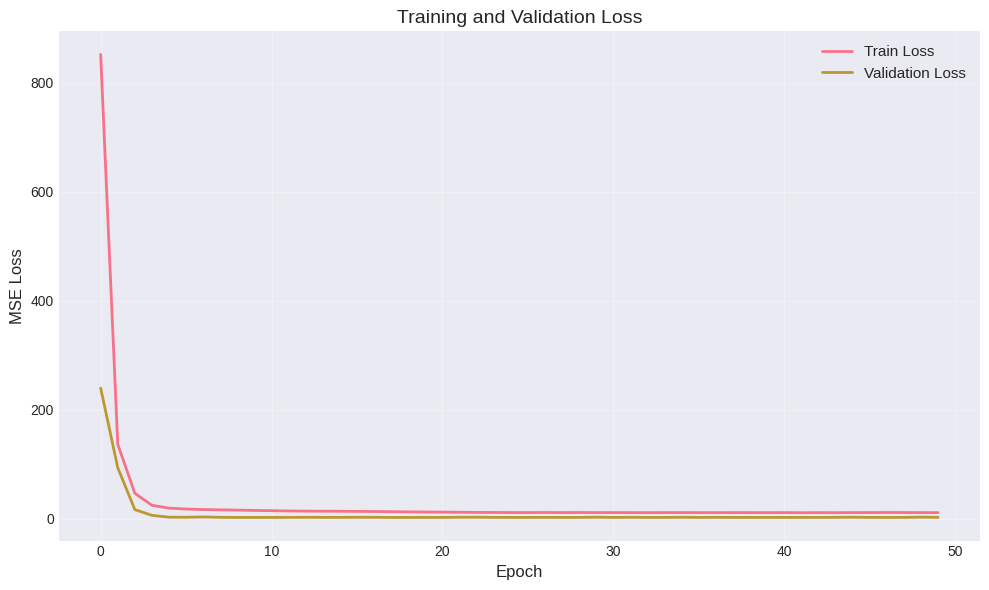

In [11]:
# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Evaluation and Visualization

In [12]:
# Load best model
model.load_state_dict(torch.load('best_density_gnn.pt'))
model.eval()

# Make predictions on validation set
predictions = []
targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch)
        predictions.append(out.cpu().numpy())
        targets.append(batch.y.cpu().numpy())

predictions = np.concatenate(predictions)
targets = np.concatenate(targets)

# Calculate metrics
mse = np.mean((predictions - targets) ** 2)
mae = np.mean(np.abs(predictions - targets))
r2 = 1 - np.sum((targets - predictions) ** 2) / np.sum((targets - targets.mean()) ** 2)

print(f"Validation Metrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  R²: {r2:.6f}")

Validation Metrics:
  MSE: 2.665022
  MAE: 0.286683
  R²: 0.998337


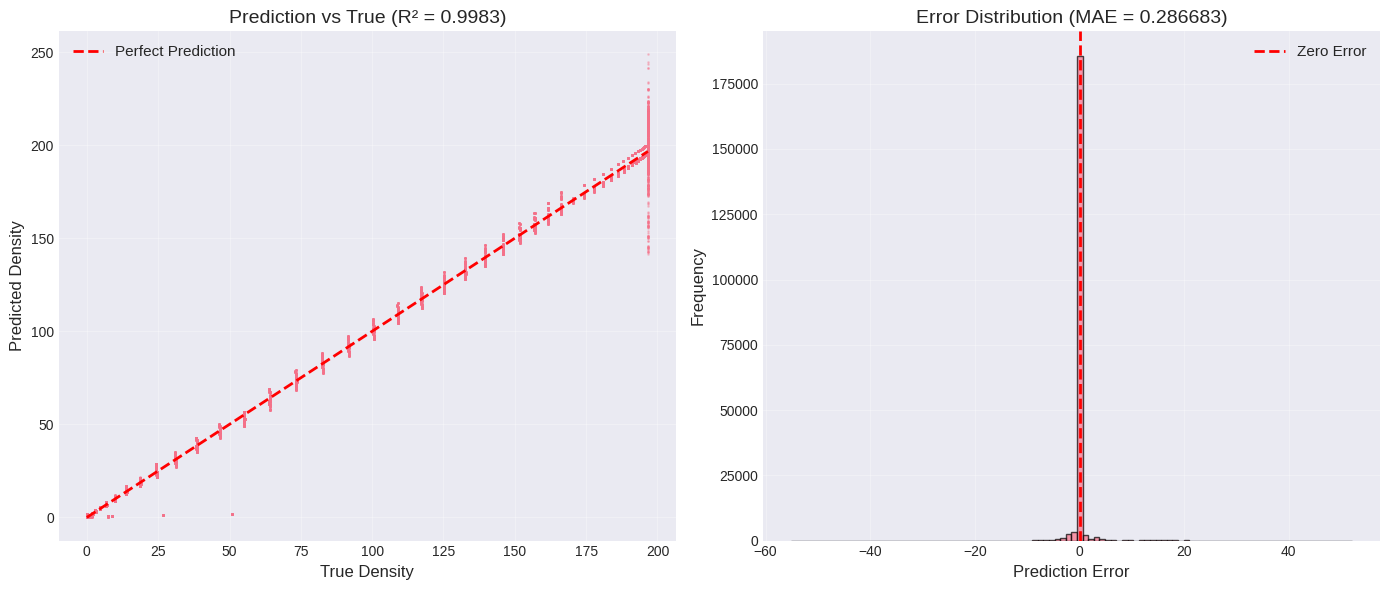

In [13]:
# Prediction vs Target scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(targets, predictions, alpha=0.3, s=1)
axes[0].plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True Density', fontsize=12)
axes[0].set_ylabel('Predicted Density', fontsize=12)
axes[0].set_title(f'Prediction vs True (R² = {r2:.4f})', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = predictions - targets
axes[1].hist(errors, bins=100, alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Error Distribution (MAE = {mae:.6f})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7.1. Detailed Error Analysis

Let's analyze where the model performs well and where it struggles.

In [14]:
# Detailed error metrics by percentile
errors_abs = np.abs(predictions - targets)
relative_errors = errors_abs / (np.abs(targets) + 1e-10)

print("=" * 60)
print("DETAILED ERROR ANALYSIS")
print("=" * 60)
print(f"\nAbsolute Error Statistics:")
print(f"  Mean Absolute Error (MAE): {mae:.6f}")
print(f"  Median Absolute Error: {np.median(errors_abs):.6f}")
print(f"  90th Percentile: {np.percentile(errors_abs, 90):.6f}")
print(f"  95th Percentile: {np.percentile(errors_abs, 95):.6f}")
print(f"  99th Percentile: {np.percentile(errors_abs, 99):.6f}")
print(f"  Max Error: {np.max(errors_abs):.6f}")

print(f"\nRelative Error Statistics (%):")
print(f"  Mean Relative Error: {np.mean(relative_errors) * 100:.3f}%")
print(f"  Median Relative Error: {np.median(relative_errors) * 100:.3f}%")
print(f"  90th Percentile: {np.percentile(relative_errors, 90) * 100:.3f}%")

print(f"\nSquared Error Statistics:")
print(f"  Mean Squared Error (MSE): {mse:.6f}")
print(f"  Root Mean Squared Error (RMSE): {np.sqrt(mse):.6f}")

print(f"\nPrediction Quality:")
print(f"  R² Score: {r2:.6f}")
print(f"  Points within 0.1 error: {np.sum(errors_abs < 0.1) / len(errors_abs) * 100:.2f}%")
print(f"  Points within 0.5 error: {np.sum(errors_abs < 0.5) / len(errors_abs) * 100:.2f}%")
print(f"  Points within 1.0 error: {np.sum(errors_abs < 1.0) / len(errors_abs) * 100:.2f}%")
print("=" * 60)

DETAILED ERROR ANALYSIS

Absolute Error Statistics:
  Mean Absolute Error (MAE): 0.286683
  Median Absolute Error: 0.017926
  90th Percentile: 0.199886
  95th Percentile: 1.377018
  99th Percentile: 5.672477
  Max Error: 55.156967

Relative Error Statistics (%):
  Mean Relative Error: 447100512.000%
  Median Relative Error: 52.076%
  90th Percentile: 2903231.750%

Squared Error Statistics:
  Mean Squared Error (MSE): 2.665022
  Root Mean Squared Error (RMSE): 1.632489

Prediction Quality:
  R² Score: 0.998337
  Points within 0.1 error: 85.95%
  Points within 0.5 error: 92.65%
  Points within 1.0 error: 94.03%


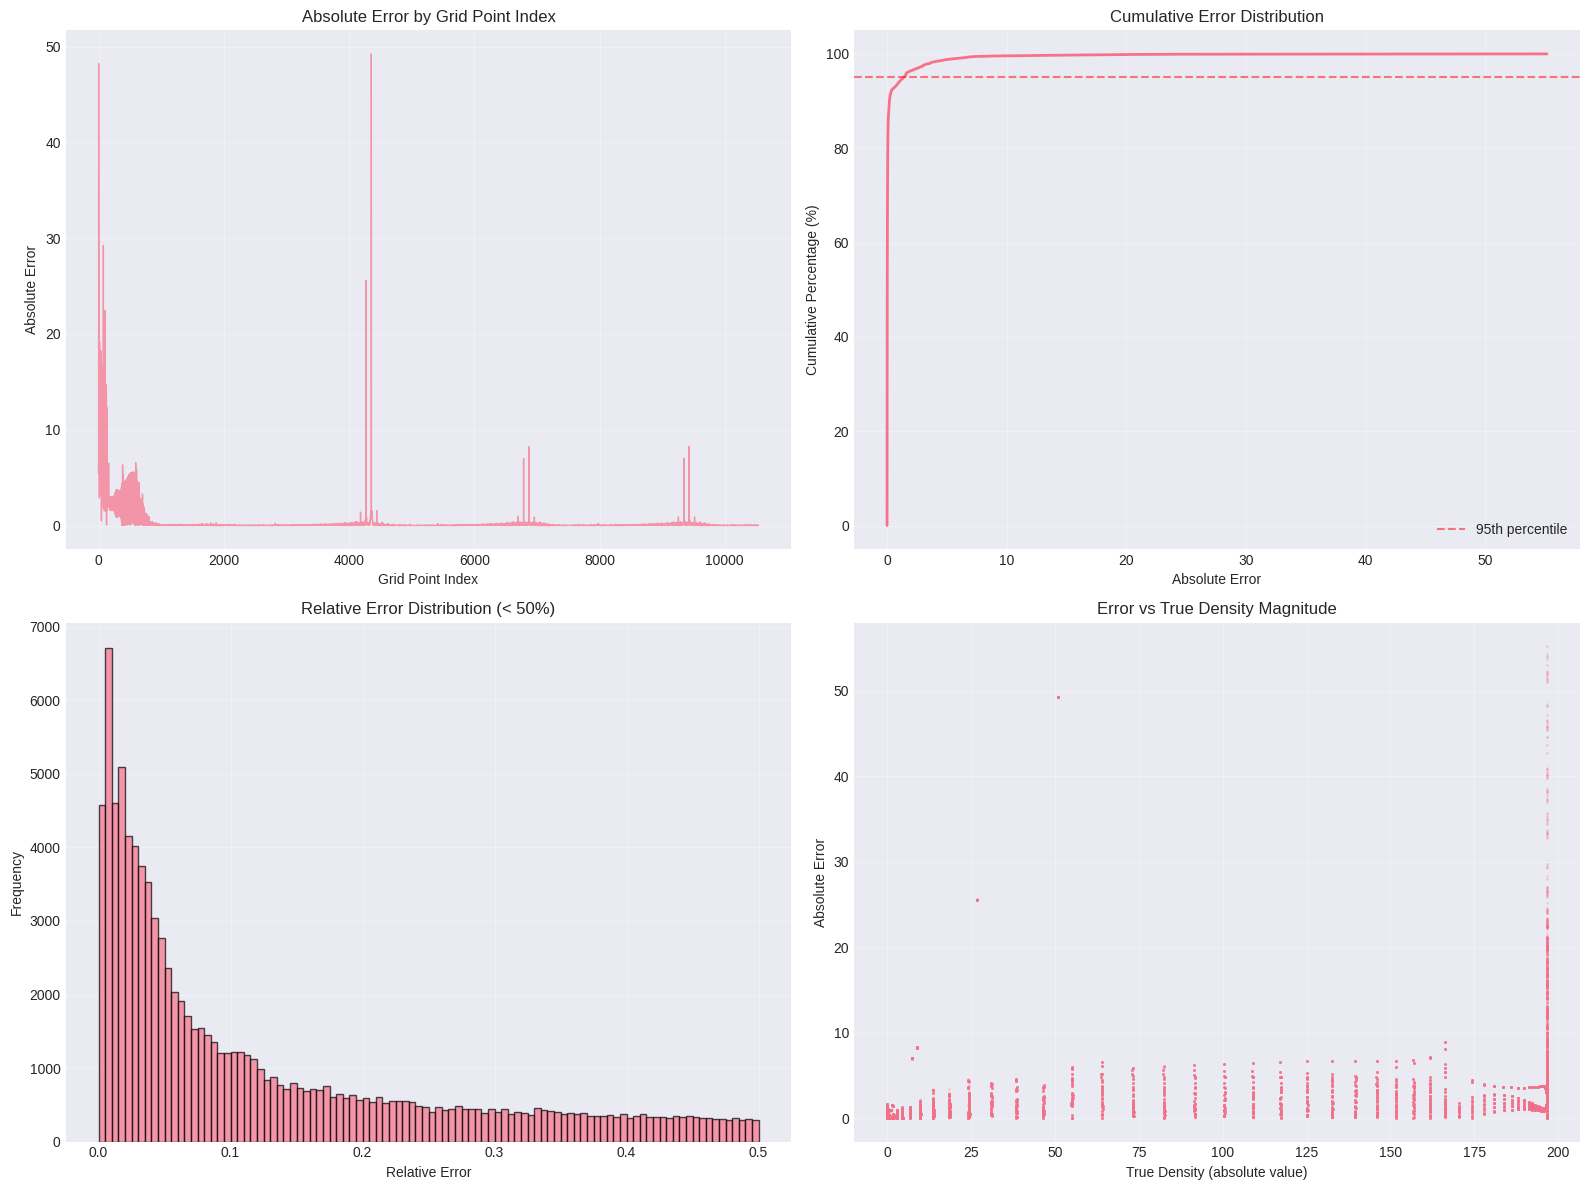

In [15]:
# Visualize error distribution by grid point position
# This helps identify if certain regions have higher errors
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Error by position (first validation sample reshaped)
sample_size = sample_data.y.shape[0]
sample_errors = errors_abs[:sample_size]

axes[0, 0].plot(sample_errors, linewidth=1, alpha=0.7)
axes[0, 0].set_title('Absolute Error by Grid Point Index', fontsize=12)
axes[0, 0].set_xlabel('Grid Point Index')
axes[0, 0].set_ylabel('Absolute Error')
axes[0, 0].grid(True, alpha=0.3)

# Cumulative error distribution
sorted_errors = np.sort(errors_abs)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
axes[0, 1].plot(sorted_errors, cumulative, linewidth=2)
axes[0, 1].set_title('Cumulative Error Distribution', fontsize=12)
axes[0, 1].set_xlabel('Absolute Error')
axes[0, 1].set_ylabel('Cumulative Percentage (%)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(95, color='r', linestyle='--', alpha=0.5, label='95th percentile')
axes[0, 1].legend()

# Relative error histogram
axes[1, 0].hist(relative_errors[relative_errors < 0.5], bins=100, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Relative Error Distribution (< 50%)', fontsize=12)
axes[1, 0].set_xlabel('Relative Error')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Error vs magnitude
axes[1, 1].scatter(np.abs(targets), errors_abs, alpha=0.2, s=1)
axes[1, 1].set_title('Error vs True Density Magnitude', fontsize=12)
axes[1, 1].set_xlabel('True Density (absolute value)')
axes[1, 1].set_ylabel('Absolute Error')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7.2. Visualize Electron Density Evolution

Compare the initial state, predicted future state, and actual future state to see how well our model captures the temporal evolution.

In [16]:
# Get a specific validation sample to visualize
val_idx = 5  # Choose which validation sample to visualize
val_sample = val_dataset[val_idx]

# Get input timesteps (lookback)
start_idx = train_size + val_idx
input_densities = []
for i in range(start_idx, start_idx + ammonia_dataset.lookback):
    density = load_density_file(ammonia_files[i])
    input_densities.append(density)

# Get actual target
actual_target = load_density_file(ammonia_files[start_idx + ammonia_dataset.lookback + ammonia_dataset.lookahead - 1])

# Get model prediction
model.eval()
with torch.no_grad():
    val_sample_device = val_sample.to(device)
    predicted_target = model(val_sample_device).cpu().numpy()

# Get timestep numbers for labeling
initial_timestep = start_idx
target_timestep = start_idx + ammonia_dataset.lookback + ammonia_dataset.lookahead - 1

print(f"Visualization of Sample #{val_idx}")
print(f"Initial state: timestep {initial_timestep * 5}")
print(f"Target state: timestep {target_timestep * 5}")
print(f"Prediction look-ahead: {ammonia_dataset.lookahead * 5} timesteps")
print(f"Using {ammonia_dataset.lookback} previous timesteps as input")

Visualization of Sample #5
Initial state: timestep 395
Target state: timestep 430
Prediction look-ahead: 25 timesteps
Using 3 previous timesteps as input


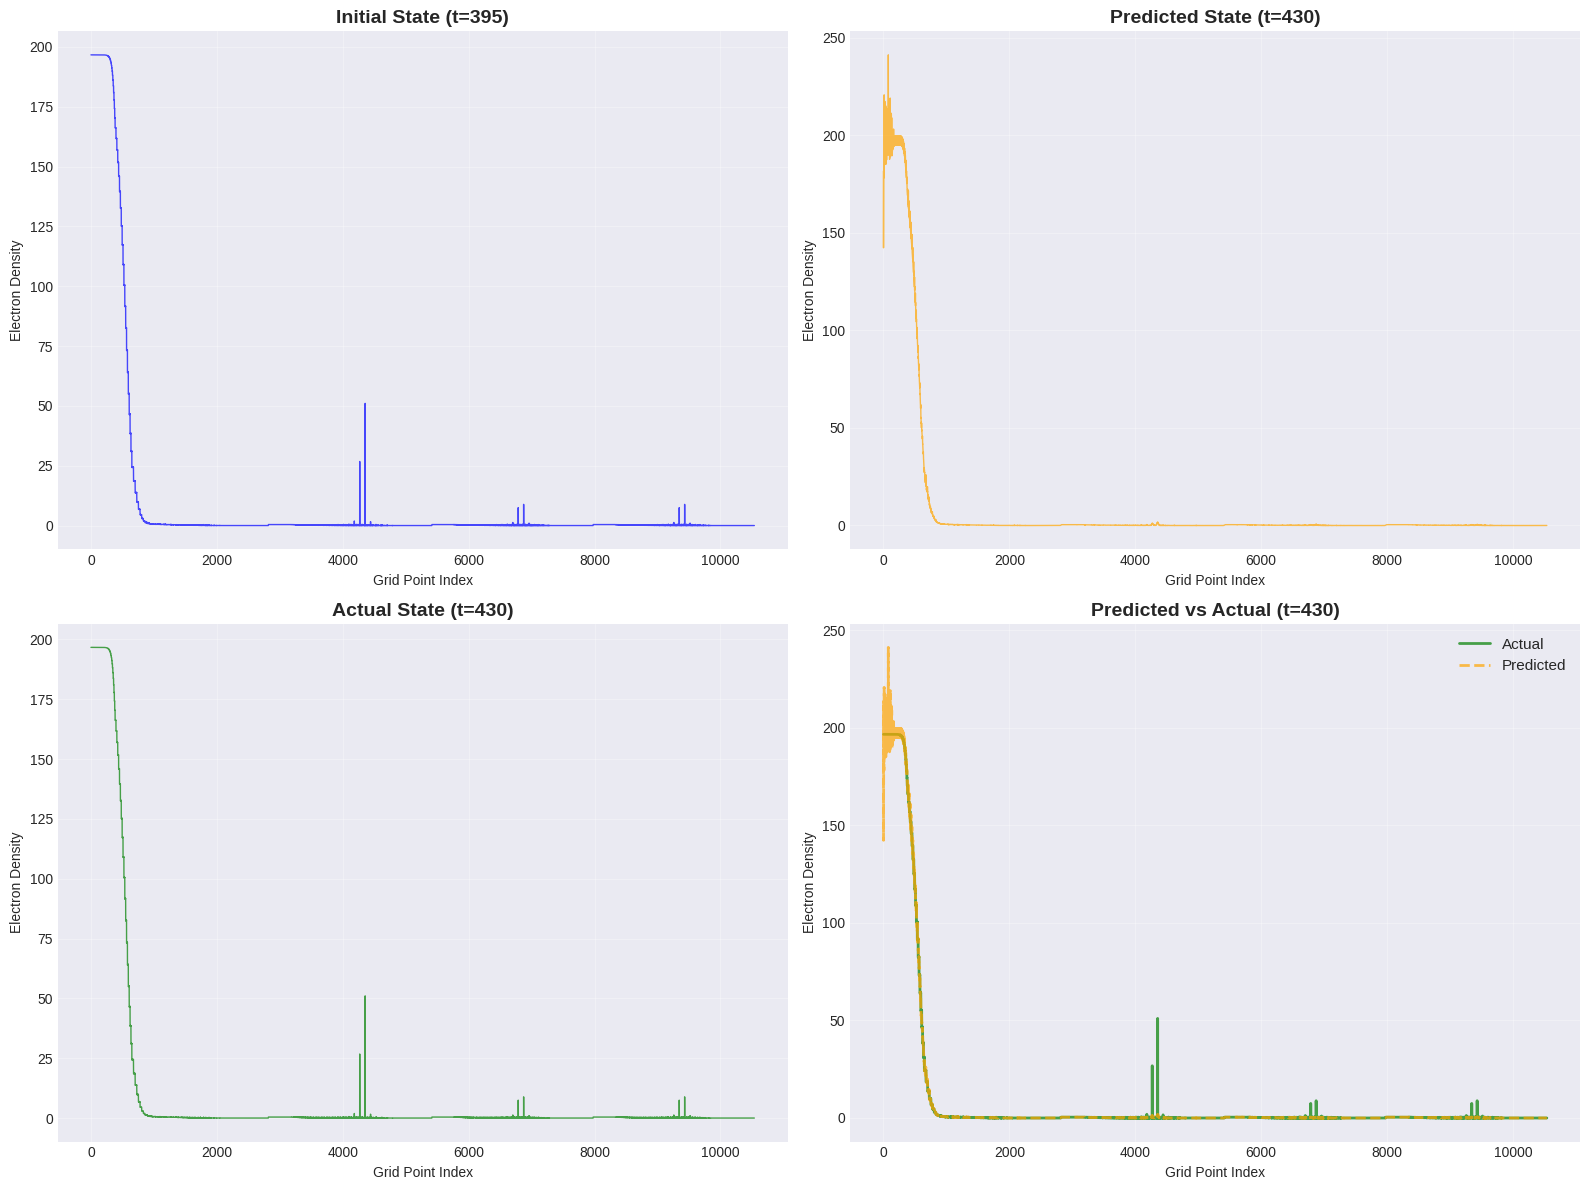


Sample-specific metrics:
  Mean Absolute Error: 0.279583
  Max Error: 54.316246
  R² Score: 0.998370


In [17]:
# Visualize: Initial vs Predicted vs Actual
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Initial state (last input timestep)
initial_state = input_densities[-1]
axes[0, 0].plot(initial_state, linewidth=1, color='blue', alpha=0.7)
axes[0, 0].set_title(f'Initial State (t={initial_timestep * 5})', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Grid Point Index')
axes[0, 0].set_ylabel('Electron Density')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Predicted future state
axes[0, 1].plot(predicted_target, linewidth=1, color='orange', alpha=0.7)
axes[0, 1].set_title(f'Predicted State (t={target_timestep * 5})', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Grid Point Index')
axes[0, 1].set_ylabel('Electron Density')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Actual future state
axes[1, 0].plot(actual_target, linewidth=1, color='green', alpha=0.7)
axes[1, 0].set_title(f'Actual State (t={target_timestep * 5})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Grid Point Index')
axes[1, 0].set_ylabel('Electron Density')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Comparison - Predicted vs Actual
axes[1, 1].plot(actual_target, linewidth=2, color='green', alpha=0.7, label='Actual')
axes[1, 1].plot(predicted_target, linewidth=2, color='orange', alpha=0.7, label='Predicted', linestyle='--')
axes[1, 1].set_title(f'Predicted vs Actual (t={target_timestep * 5})', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Grid Point Index')
axes[1, 1].set_ylabel('Electron Density')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate error for this specific sample
sample_error = np.abs(predicted_target - actual_target)
print(f"\nSample-specific metrics:")
print(f"  Mean Absolute Error: {np.mean(sample_error):.6f}")
print(f"  Max Error: {np.max(sample_error):.6f}")
print(f"  R² Score: {1 - np.sum((actual_target - predicted_target)**2) / np.sum((actual_target - actual_target.mean())**2):.6f}")

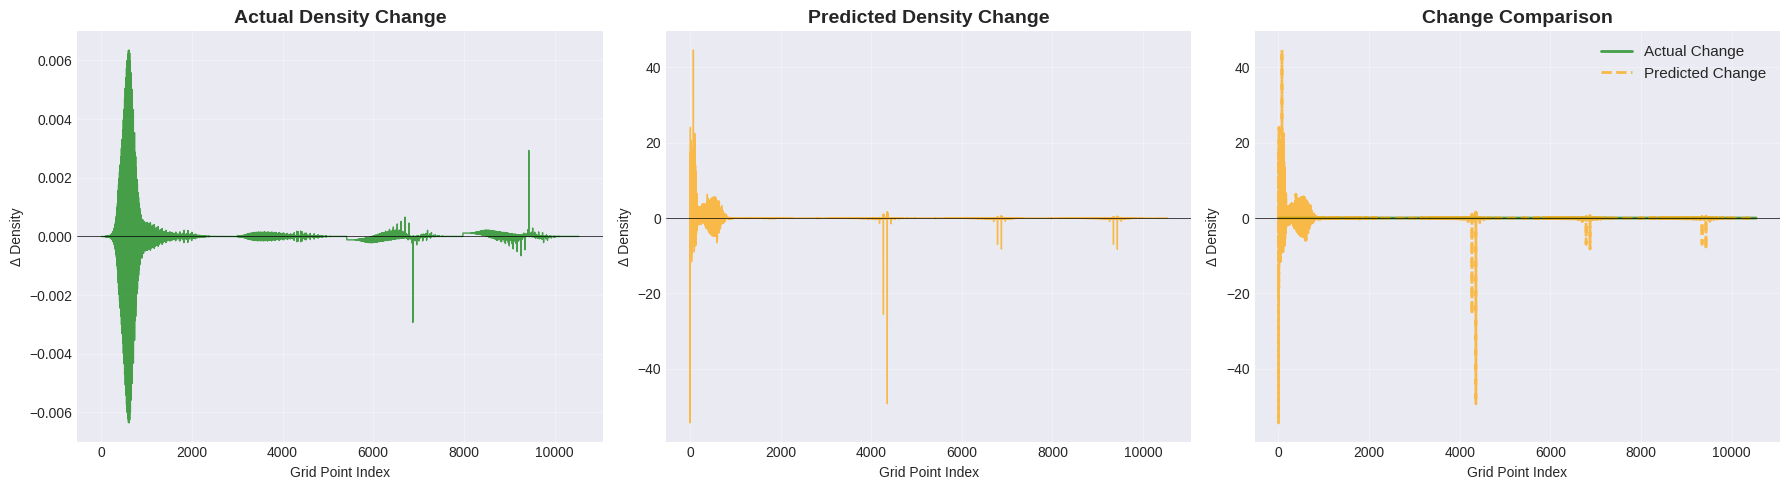


Density Change Statistics:
  Actual change - Mean: -0.000000, Std: 0.000533
  Predicted change - Mean: -0.015468, Std: 1.616334


In [18]:
# Show density change over time (delta)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Change from initial to actual
actual_change = actual_target - initial_state
axes[0].plot(actual_change, linewidth=1, color='green', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Actual Density Change', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grid Point Index')
axes[0].set_ylabel('Δ Density')
axes[0].grid(True, alpha=0.3)

# Change from initial to predicted
predicted_change = predicted_target - initial_state
axes[1].plot(predicted_change, linewidth=1, color='orange', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Predicted Density Change', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grid Point Index')
axes[1].set_ylabel('Δ Density')
axes[1].grid(True, alpha=0.3)

# Comparison of changes
axes[2].plot(actual_change, linewidth=2, color='green', alpha=0.7, label='Actual Change')
axes[2].plot(predicted_change, linewidth=2, color='orange', alpha=0.7, label='Predicted Change', linestyle='--')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('Change Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Grid Point Index')
axes[2].set_ylabel('Δ Density')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDensity Change Statistics:")
print(f"  Actual change - Mean: {np.mean(actual_change):.6f}, Std: {np.std(actual_change):.6f}")
print(f"  Predicted change - Mean: {np.mean(predicted_change):.6f}, Std: {np.std(predicted_change):.6f}")

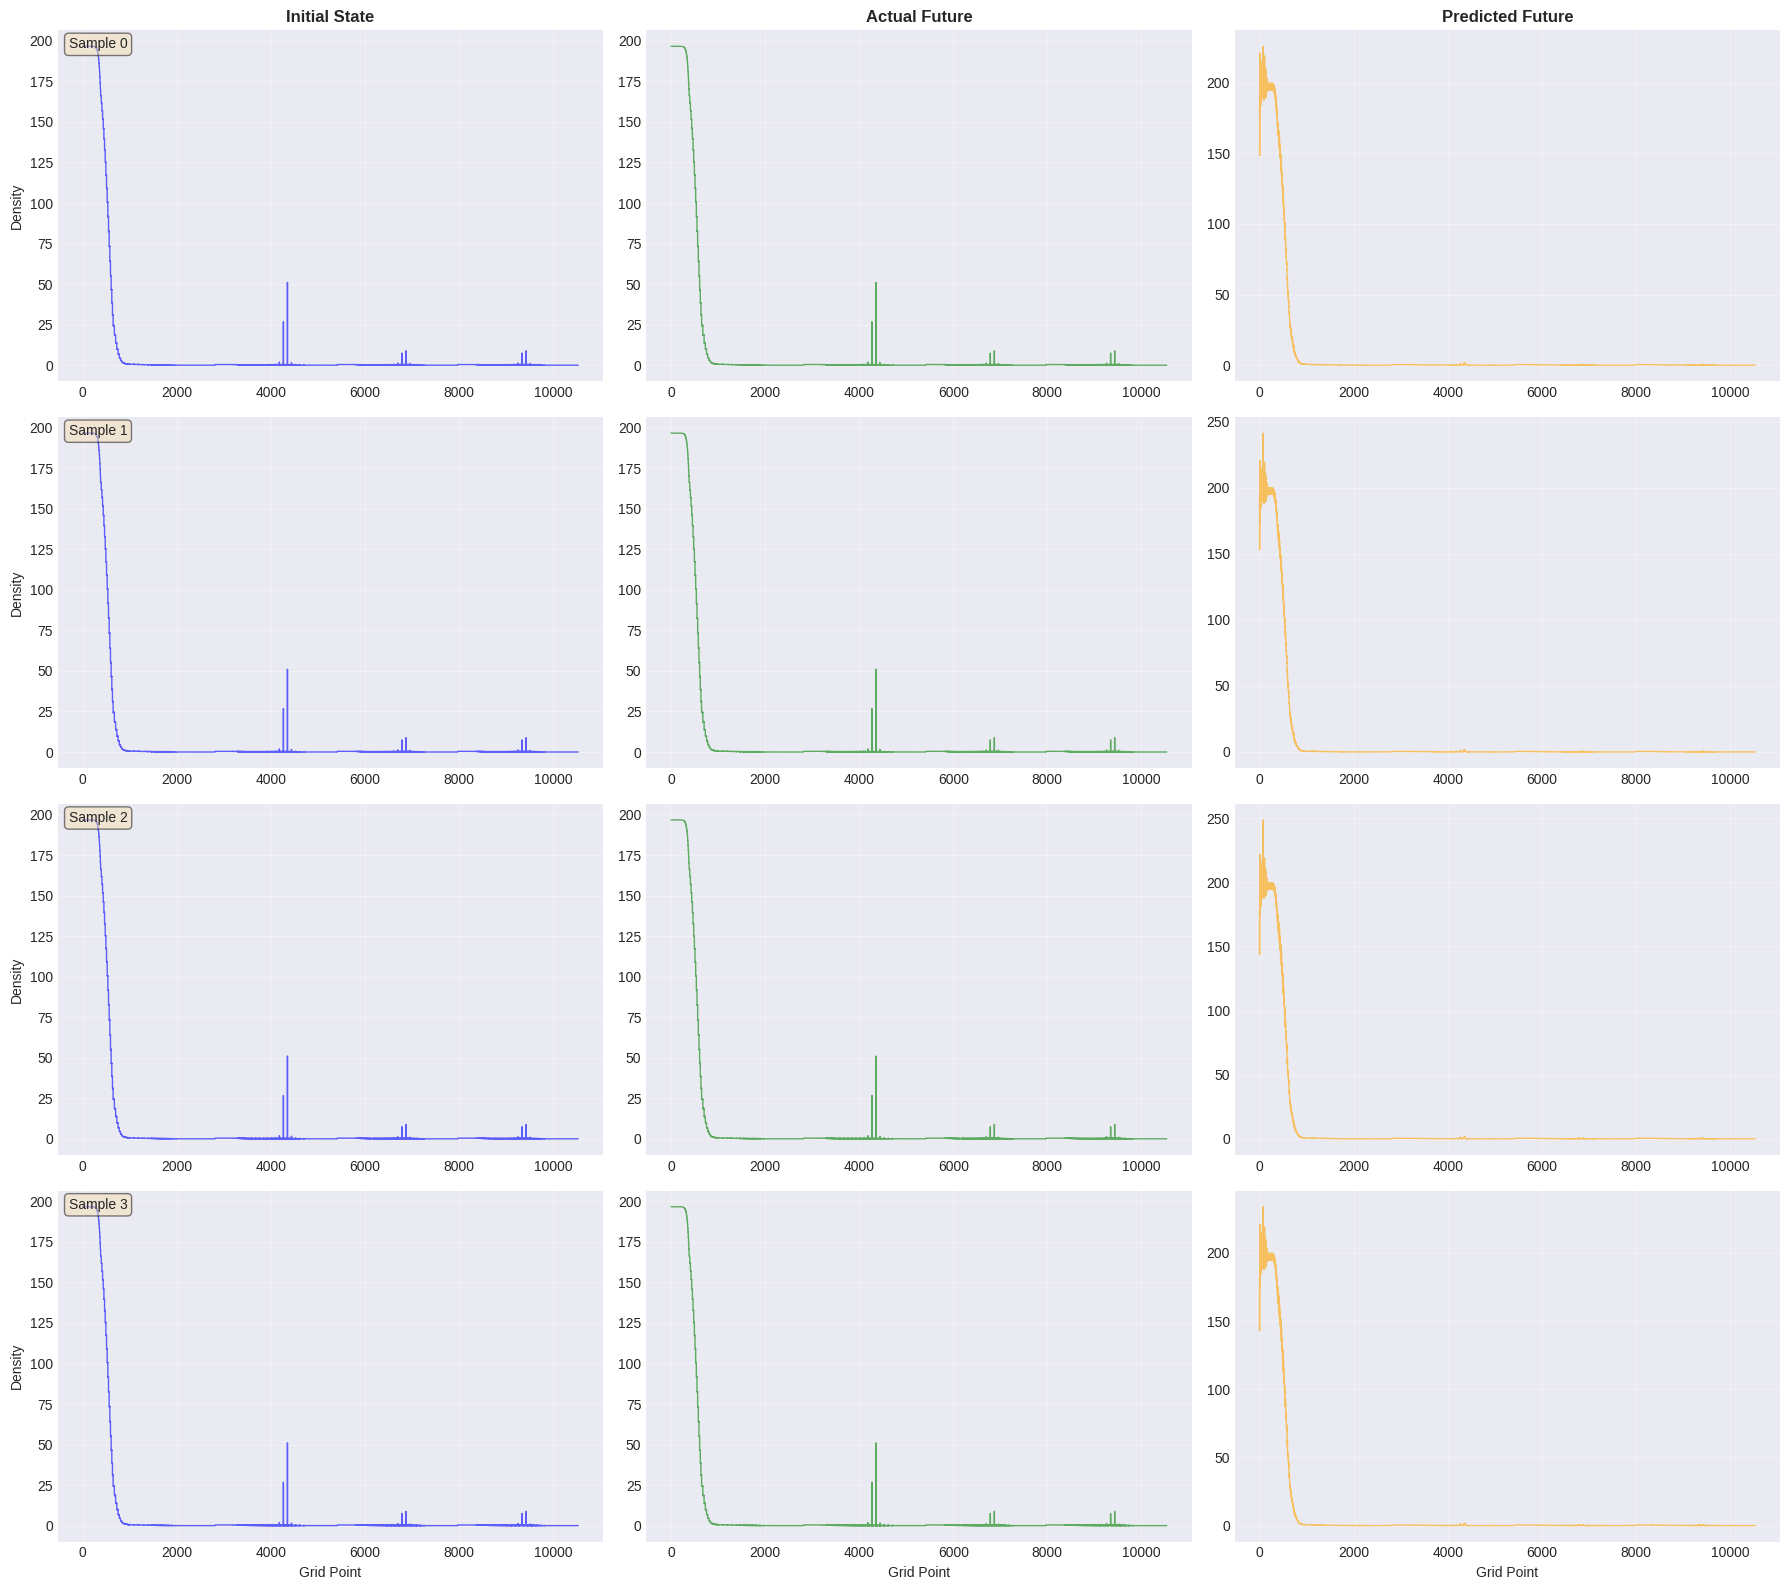

In [19]:
# Visualize multiple samples to see consistency
n_samples_to_show = 4
fig, axes = plt.subplots(n_samples_to_show, 3, figsize=(18, 4 * n_samples_to_show))

for sample_idx in range(n_samples_to_show):
    if sample_idx >= len(val_dataset):
        break
    
    # Get data for this sample
    val_sample_i = val_dataset[sample_idx]
    start_idx_i = train_size + sample_idx
    
    # Get initial state
    initial_i = load_density_file(ammonia_files[start_idx_i + ammonia_dataset.lookback - 1])
    
    # Get actual target
    actual_i = load_density_file(ammonia_files[start_idx_i + ammonia_dataset.lookback + ammonia_dataset.lookahead - 1])
    
    # Get prediction
    with torch.no_grad():
        predicted_i = model(val_sample_i.to(device)).cpu().numpy()
    
    # Plot initial
    axes[sample_idx, 0].plot(initial_i, linewidth=1, color='blue', alpha=0.6)
    axes[sample_idx, 0].set_ylabel('Density')
    if sample_idx == 0:
        axes[sample_idx, 0].set_title('Initial State', fontsize=12, fontweight='bold')
    if sample_idx == n_samples_to_show - 1:
        axes[sample_idx, 0].set_xlabel('Grid Point')
    axes[sample_idx, 0].grid(True, alpha=0.3)
    
    # Plot actual
    axes[sample_idx, 1].plot(actual_i, linewidth=1, color='green', alpha=0.6)
    if sample_idx == 0:
        axes[sample_idx, 1].set_title('Actual Future', fontsize=12, fontweight='bold')
    if sample_idx == n_samples_to_show - 1:
        axes[sample_idx, 1].set_xlabel('Grid Point')
    axes[sample_idx, 1].grid(True, alpha=0.3)
    
    # Plot prediction
    axes[sample_idx, 2].plot(predicted_i, linewidth=1, color='orange', alpha=0.6)
    if sample_idx == 0:
        axes[sample_idx, 2].set_title('Predicted Future', fontsize=12, fontweight='bold')
    if sample_idx == n_samples_to_show - 1:
        axes[sample_idx, 2].set_xlabel('Grid Point')
    axes[sample_idx, 2].grid(True, alpha=0.3)
    
    # Add sample label
    axes[sample_idx, 0].text(0.02, 0.98, f'Sample {sample_idx}', 
                              transform=axes[sample_idx, 0].transAxes,
                              verticalalignment='top', fontsize=10,
                              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7.3. Temporal Evolution of Selected Grid Points

Track how specific grid points evolve over time and compare predictions vs reality.

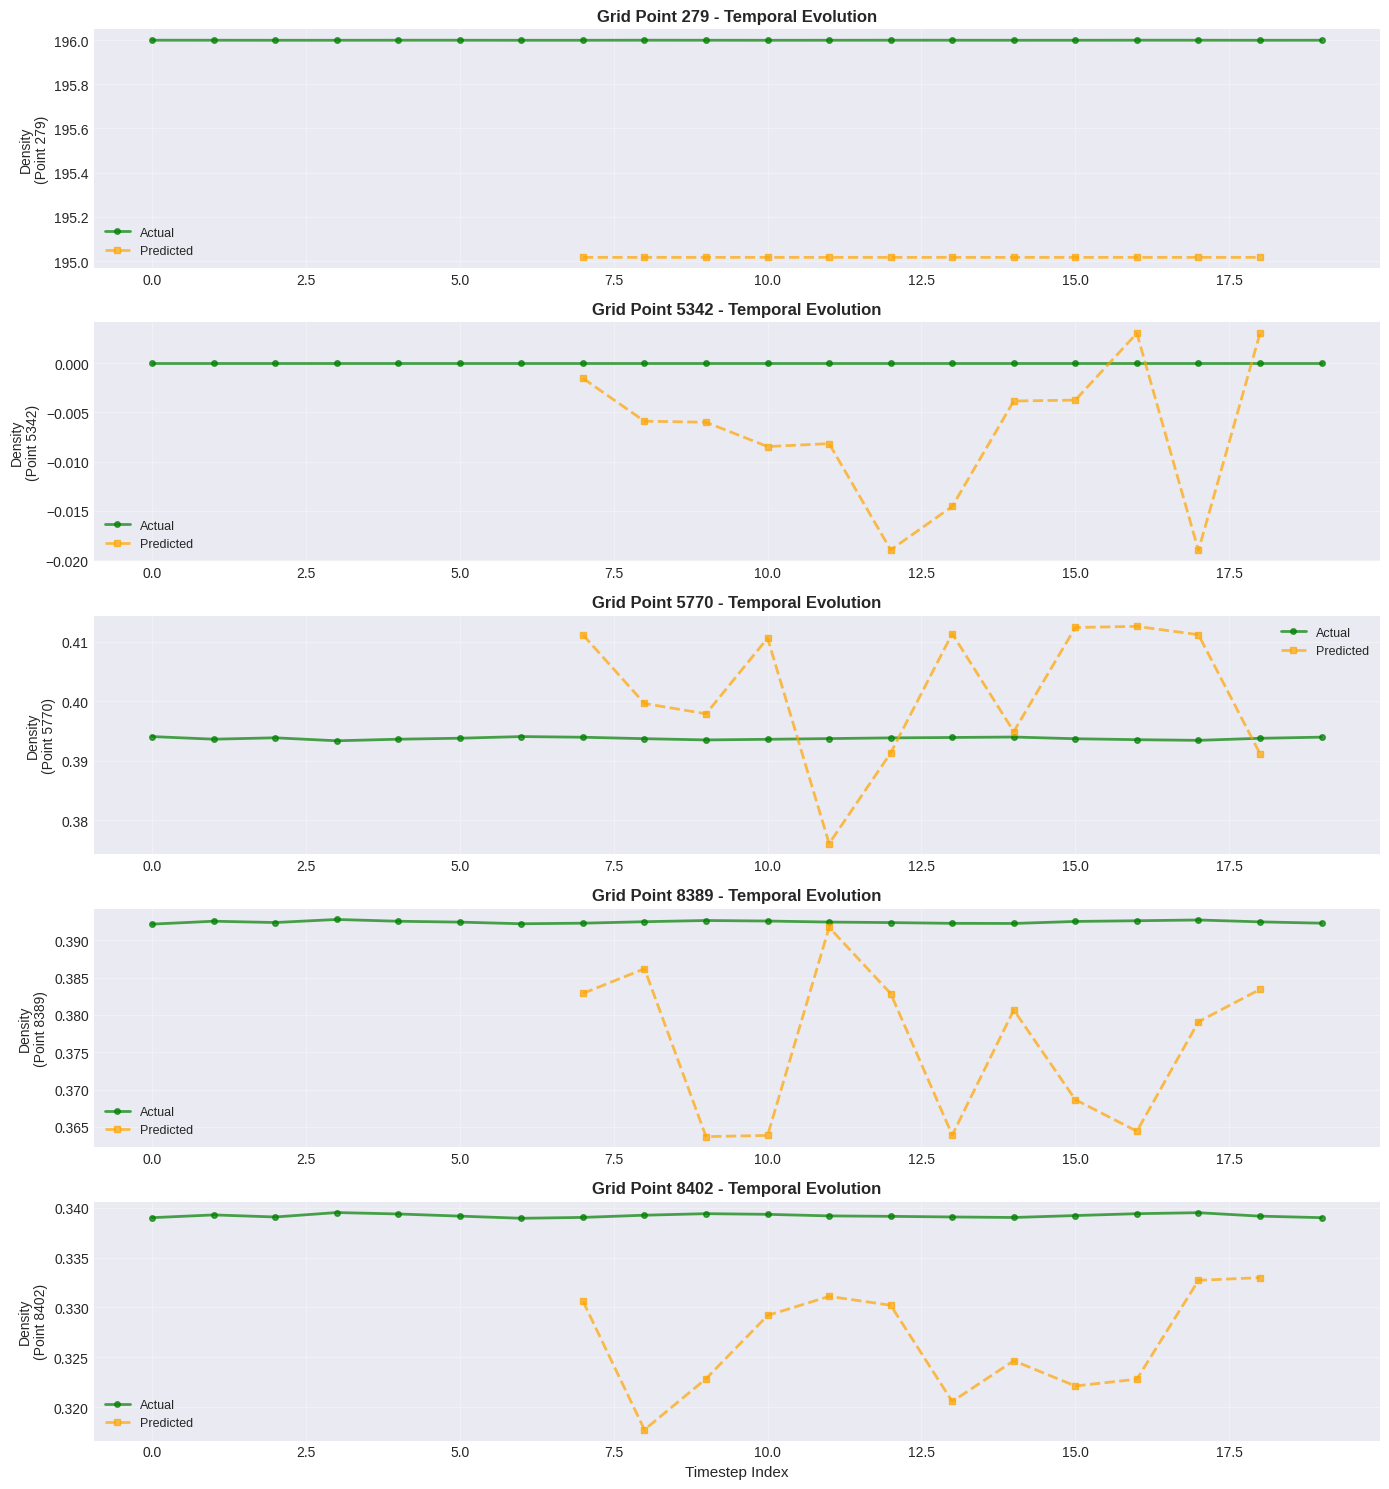

In [20]:
# Select specific grid points to track
n_points_to_track = 5
grid_points_to_track = np.random.choice(len(sample_ammonia), n_points_to_track, replace=False)
grid_points_to_track = np.sort(grid_points_to_track)

# Load a sequence of timesteps
sequence_length = 20
sequence_start = train_size
actual_sequence = []
for i in range(sequence_start, min(sequence_start + sequence_length, len(ammonia_files))):
    density = load_density_file(ammonia_files[i])
    actual_sequence.append(density)
actual_sequence = np.array(actual_sequence)  # Shape: (timesteps, grid_points)

# Create predictions for the same sequence (multi-step ahead)
# Note: This is one-step prediction, for true sequence we'd need autoregressive prediction
predicted_sequence = []
for i in range(len(val_dataset)):
    if i >= sequence_length - ammonia_dataset.lookback - ammonia_dataset.lookahead:
        break
    val_sample_i = val_dataset[i]
    with torch.no_grad():
        pred = model(val_sample_i.to(device)).cpu().numpy()
    predicted_sequence.append(pred)

if len(predicted_sequence) > 0:
    predicted_sequence = np.array(predicted_sequence)
    
    # Plot evolution of selected grid points
    fig, axes = plt.subplots(n_points_to_track, 1, figsize=(14, 3 * n_points_to_track))
    
    if n_points_to_track == 1:
        axes = [axes]
    
    for idx, point in enumerate(grid_points_to_track):
        # Actual evolution
        timesteps_actual = np.arange(len(actual_sequence))
        axes[idx].plot(timesteps_actual, actual_sequence[:, point], 
                      marker='o', linewidth=2, color='green', alpha=0.7, 
                      label='Actual', markersize=4)
        
        # Predicted evolution (offset by lookback + lookahead)
        if point < predicted_sequence.shape[1]:
            timesteps_pred = np.arange(ammonia_dataset.lookback + ammonia_dataset.lookahead - 1, 
                                       ammonia_dataset.lookback + ammonia_dataset.lookahead - 1 + len(predicted_sequence))
            axes[idx].plot(timesteps_pred[:min(len(predicted_sequence), len(actual_sequence) - timesteps_pred[0])], 
                          predicted_sequence[:min(len(predicted_sequence), len(actual_sequence) - timesteps_pred[0]), point],
                          marker='s', linewidth=2, color='orange', alpha=0.7, 
                          label='Predicted', markersize=4, linestyle='--')
        
        axes[idx].set_ylabel(f'Density\n(Point {point})', fontsize=10)
        axes[idx].set_title(f'Grid Point {point} - Temporal Evolution', fontsize=12, fontweight='bold')
        axes[idx].legend(loc='best', fontsize=9)
        axes[idx].grid(True, alpha=0.3)
        
        if idx == n_points_to_track - 1:
            axes[idx].set_xlabel('Timestep Index', fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough validation samples for sequence prediction visualization")

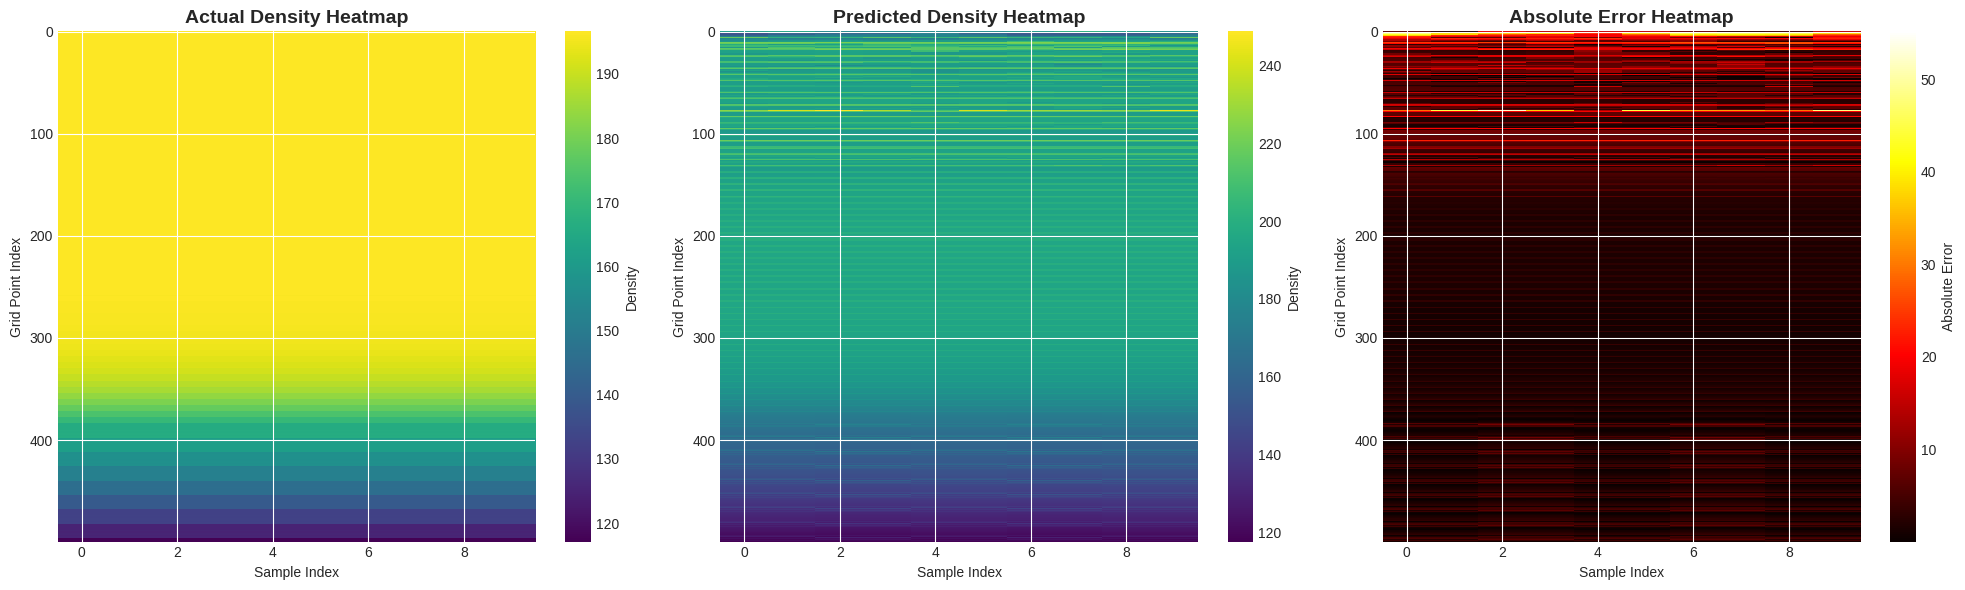


Heatmap Statistics (first 500 grid points, 10 samples):
  Mean Error: 4.062750
  Max Error: 55.156965
  Grid points with error > 1.0: 4308 / 5000


In [21]:
# Heatmap comparison: reshape data for better visualization
# We'll show a subset of grid points over multiple timesteps
n_samples_heatmap = min(10, len(val_dataset))
n_points_heatmap = 500  # Show first 500 grid points

actual_grid = []
predicted_grid = []

for i in range(n_samples_heatmap):
    val_sample_i = val_dataset[i]
    start_idx_i = train_size + i
    
    # Get actual
    actual_i = load_density_file(ammonia_files[start_idx_i + ammonia_dataset.lookback + ammonia_dataset.lookahead - 1])
    actual_grid.append(actual_i[:n_points_heatmap])
    
    # Get prediction
    with torch.no_grad():
        pred_i = model(val_sample_i.to(device)).cpu().numpy()
    predicted_grid.append(pred_i[:n_points_heatmap])

actual_grid = np.array(actual_grid)
predicted_grid = np.array(predicted_grid)
error_grid = np.abs(actual_grid - predicted_grid)

# Create heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual
im1 = axes[0].imshow(actual_grid.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title('Actual Density Heatmap', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Grid Point Index')
plt.colorbar(im1, ax=axes[0], label='Density')

# Predicted
im2 = axes[1].imshow(predicted_grid.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[1].set_title('Predicted Density Heatmap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Grid Point Index')
plt.colorbar(im2, ax=axes[1], label='Density')

# Error
im3 = axes[2].imshow(error_grid.T, aspect='auto', cmap='hot', interpolation='nearest')
axes[2].set_title('Absolute Error Heatmap', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Grid Point Index')
plt.colorbar(im3, ax=axes[2], label='Absolute Error')

plt.tight_layout()
plt.show()

print(f"\nHeatmap Statistics (first {n_points_heatmap} grid points, {n_samples_heatmap} samples):")
print(f"  Mean Error: {np.mean(error_grid):.6f}")
print(f"  Max Error: {np.max(error_grid):.6f}")
print(f"  Grid points with error > 1.0: {np.sum(error_grid > 1.0)} / {error_grid.size}")

## 7.4. Interpretation Guide

**What to look for in the visualizations:**

1. **Error Analysis (Section 7.1)**:
   - **MAE/MSE values**: Lower is better. Compare to the range of your data.
   - **Percentile errors**: Shows if most predictions are good, or if there are outliers.
   - **R² score**: Closer to 1.0 means better fit (0.8+ is typically good).
   - **Points within X error**: Shows percentage of predictions that are "close enough".

2. **Density Evolution (Section 7.2)**:
   - **Initial → Actual**: Shows how density actually changes over time.
   - **Initial → Predicted**: Shows what your model thinks will happen.
   - **Comparison**: If curves overlap well, your model captures the physics!
   - **Change plots**: Shows if model understands which regions increase/decrease.

3. **Multiple Samples (Section 7.2)**:
   - Check if model performs consistently across different samples.
   - Look for patterns: does it always over/under-predict in certain regions?

4. **Temporal Tracking (Section 7.3)**:
   - Shows if model captures trends (increasing/decreasing patterns).
   - Large divergence = model loses track of dynamics over time.

5. **Heatmaps (Section 7.3)**:
   - **Patterns**: Similar patterns in actual vs predicted = good!
   - **Hot spots in error map**: Identifies problematic grid regions.
   - Uniform colors = consistent performance.

**Good signs:**
- R² > 0.8
- Most errors < 1% of data range  
- Predicted and actual curves follow same trends
- Error heatmap shows no strong patterns (random errors)

**Warning signs:**
- R² < 0.5
- Large systematic errors in specific regions
- Model misses important density changes
- Error patterns correlated with grid position

## 8. Future Work and Improvements

**Model Improvements:**
1. Try Graph Attention Networks (GAT) for better edge weighting
2. Implement temporal convolutions or RNN/LSTM layers
3. Multi-task learning: predict multiple future timesteps
4. Add residual connections for deeper networks

**Data Enhancements:**
1. Incorporate actual 3D grid coordinates if available
2. Use both ammonia and water for transfer learning
3. Data augmentation techniques
4. Normalize/standardize features

**Graph Construction:**
1. Learn edge weights dynamically
2. Use attention mechanisms to determine connectivity
3. Experiment with different neighborhood sizes
4. Build multi-scale graphs (coarse and fine)

**Evaluation:**
1. Long-term prediction accuracy (autoregressive prediction)
2. Physical constraint validation
3. Domain-specific metrics for quantum chemistry